# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## Finishing off with Random Forests & Ensemble

In [1]:
# imports

import os
import re
import math
import json
from tqdm import tqdm
import random
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import chromadb
from items import Item
from testing import Tester
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib


In [2]:
# CONSTANTS

QUESTION = "How much does this cost to the nearest dollar?\n\n"
DB = "products_vectorstore"

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [4]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
# Another import after Logging in to Hugging Face - thank you Trung N.!

from items import Item

In [6]:
# Load in the test pickle file:

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [7]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [8]:
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
prices = [metadata['price'] for metadata in result['metadatas']]

In [9]:
prices

[226.95,
 506.98,
 405.0,
 1.95,
 246.93,
 75.99,
 144.95,
 174.99,
 349.95,
 52.99,
 31.27,
 135.0,
 59.99,
 165.99,
 125.81,
 59.99,
 930.0,
 68.56,
 25.47,
 146.95,
 244.99,
 94.99,
 27.9,
 319.95,
 324.99,
 380.31,
 117.13,
 399.98,
 52.0,
 182.31,
 111.16,
 107.97,
 80.95,
 162.95,
 4.5,
 749.99,
 135.99,
 52.95,
 122.99,
 141.76,
 237.99,
 269.99,
 344.98,
 102.99,
 337.67,
 237.0,
 145.95,
 299.99,
 154.95,
 157.99,
 30.9,
 216.99,
 299.99,
 142.26,
 20.99,
 165.48,
 28.99,
 349.99,
 157.95,
 8.99,
 127.0,
 119.99,
 449.9,
 504.9,
 96.0,
 399.0,
 483.99,
 229.99,
 974.3,
 48.0,
 162.0,
 32.99,
 46.9,
 23.98,
 291.95,
 43.99,
 549.0,
 144.95,
 399.99,
 278.91,
 310.99,
 38.08,
 599.0,
 299.99,
 281.66,
 478.0,
 68.99,
 229.0,
 118.88,
 399.49,
 289.0,
 213.92,
 132.3,
 219.25,
 172.99,
 845.0,
 379.92,
 48.83,
 195.0,
 366.0,
 112.99,
 30.07,
 84.99,
 101.99,
 429.99,
 117.5,
 130.72,
 15.99,
 532.99,
 149.99,
 274.35,
 284.95,
 110.0,
 405.69,
 95.0,
 225.88,
 151.07,
 35.91,
 5

# Random Forest

We will now train a Random Forest model.

Can you spot the difference from what we did in Week 6? In week 6 we used the word2vec model to form vectors; this time we'll use the vectors we already have in Chroma, from the SentenceTransformer model.

In [10]:
# This next line takes an hour on my M1 Mac!

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(vectors, prices)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Save the model to a file

joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [12]:
# Load it back in again

rf_model = joblib.load('random_forest_model.pkl')

In [13]:
from agents.specialist_agent import SpecialistAgent
from agents.frontier_agent import FrontierAgent
from agents.random_forest_agent import RandomForestAgent

In [14]:
specialist = SpecialistAgent()
frontier = FrontierAgent(collection)
random_forest = RandomForestAgent()

In [15]:
def description(item):
    return item.prompt.split("to the nearest dollar?\n\n")[1].split("\n\nPrice is $")[0]

In [16]:
def rf(item):
    return random_forest.price(description(item))

1: Guess: $278.39 Truth: $374.41 Error: $96.02 SLE: 0.09 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $176.17 Truth: $225.11 Error: $48.94 SLE: 0.06 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $239.18 Truth: $61.68 Error: $177.50 SLE: 1.80 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $310.61 Truth: $599.99 Error: $289.38 SLE: 0.43 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $210.39 Truth: $16.99 Error: $193.40 SLE: 6.07 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $113.07 Truth: $31.99 Error: $81.08 SLE: 1.54 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $259.84 Truth: $101.79 Error: $158.05 SLE: 0.87 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $238.63 Truth: $289.00 Error: $50.37 SLE: 0.04 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $300.30 Truth: $635.86 Error: $335.56 SLE: 0.56 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $173.06 Truth: $65.99 Error: $107.07 SL

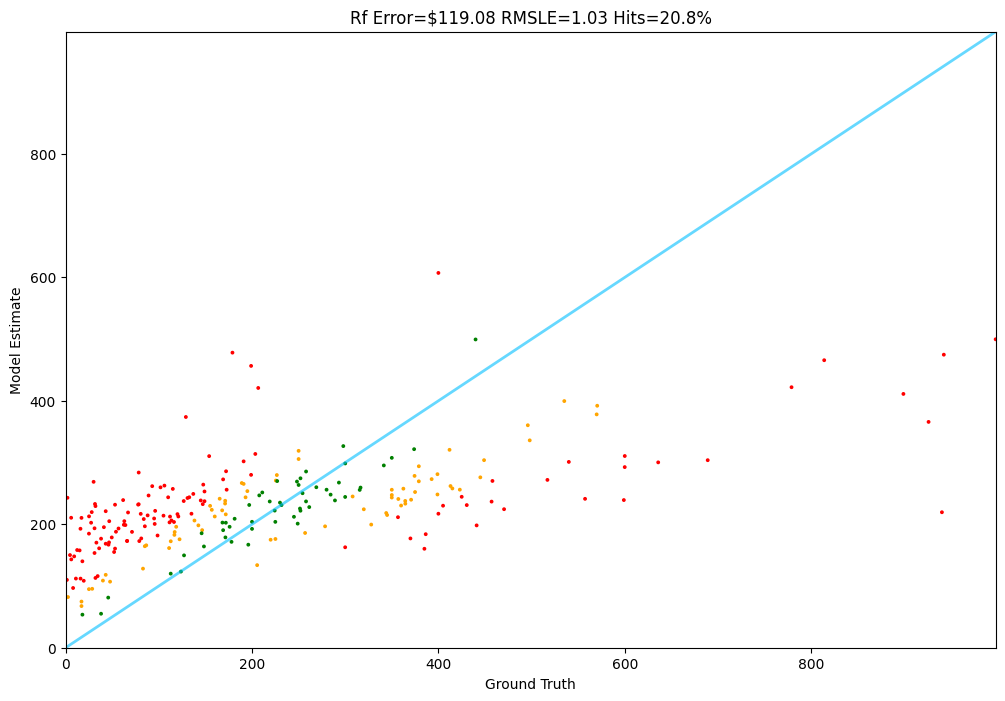

In [17]:
Tester.test(rf, test)

In [18]:
product = "Quadcast HyperX condenser mic for high quality audio for podcasting"

In [19]:
print(specialist.price(product))
print(frontier.price(product))
print(random_forest.price(product))

189.0
139.99
282.71690000000024


In [20]:
specialists = []
frontiers = []
random_forests = []
prices = []
for item in tqdm(test[1000:1250]):
    text = description(item)
    specialists.append(specialist.price(text))
    frontiers.append(frontier.price(text))
    random_forests.append(random_forest.price(text))
    prices.append(item.price)

100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [26:32<00:00,  6.37s/it]


In [21]:
mins = [min(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]
maxes = [max(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]

X = pd.DataFrame({
    'Specialist': specialists,
    'Frontier': frontiers,
    'RandomForest': random_forests,
    'Min': mins,
    'Max': maxes,
})

# Convert y to a Series
y = pd.Series(prices)

In [22]:
# Train a Linear Regression
np.random.seed(42)

lr = LinearRegression()
lr.fit(X, y)

feature_columns = X.columns.tolist()

for feature, coef in zip(feature_columns, lr.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept={lr.intercept_:.2f}")

Specialist: 0.74
Frontier: 0.13
RandomForest: -0.12
Min: 0.05
Max: 0.17
Intercept=14.49


In [23]:
joblib.dump(lr, 'ensemble_model.pkl')

['ensemble_model.pkl']

In [24]:
from agents.ensemble_agent import EnsembleAgent
ensemble = EnsembleAgent(collection)

In [25]:
ensemble.price(product)

192.27261193294905

In [26]:
def ensemble_pricer(item):
    return max(0,ensemble.price(description(item)))

1: Guess: $408.98 Truth: $374.41 Error: $34.57 SLE: 0.01 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $173.90 Truth: $225.11 Error: $51.21 SLE: 0.07 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $56.35 Truth: $61.68 Error: $5.33 SLE: 0.01 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $369.14 Truth: $599.99 Error: $230.85 SLE: 0.23 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $41.12 Truth: $16.99 Error: $24.13 SLE: 0.72 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $36.33 Truth: $31.99 Error: $4.34 SLE: 0.02 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $141.07 Truth: $101.79 Error: $39.28 SLE: 0.10 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $301.64 Truth: $289.00 Error: $12.64 SLE: 0.00 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $899.23 Truth: $635.86 Error: $263.37 SLE: 0.12 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $62.71 Truth: $65.99 Error: $3.28 SLE: 0.00 Ite

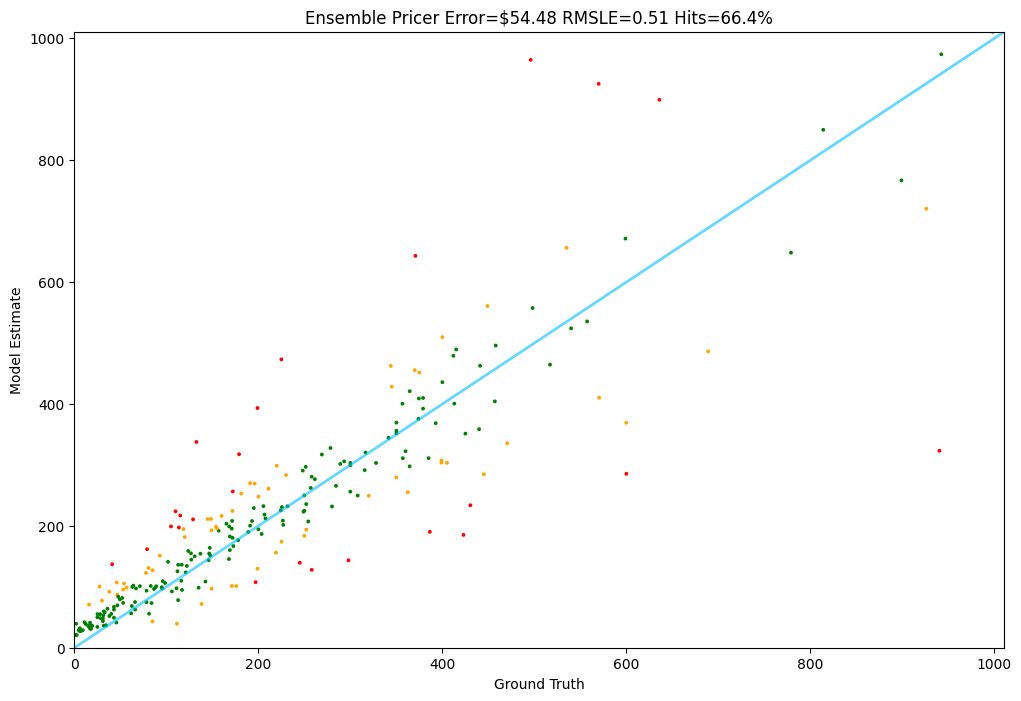

In [27]:
Tester.test(ensemble_pricer, test)

# WHAT A DAY!

We got so much done - a Fronter RAG pipeline, a Random Forest model using transformer-based encodings, and an Ensemble model.

You can do better, for sure!

Tweak this, and try adding components into the ensemble, to beat my performance.